# Fine-tuning Qwen 3.5 0.8B

In [1]:
import os
os.environ["HF_HUB_OFFLINE"] = "1"

import torch
from datasets import load_dataset
from unsloth import FastLanguageModel
from trl import SFTTrainer, SFTConfig

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [2]:
max_seq_length = 4096

dataset = load_dataset(
    "json",
    data_files={
        "train": "data/echobot_train.jsonl",
        "test": "data/echobot_test.jsonl",
    },
)
print(dataset['train'].column_names)
print(dataset['train'][0])

['id', 'query', 'label', 'source', 'tag']
{'id': 'hw-001', 'query': 'Tell me about SGA leadership over time', 'label': 0, 'source': 'handwritten', 'tag': 'clear-positive'}


In [3]:
# Define your system prompt once
system_prompt = "You are a classifier for another chatbot. Your job is to determine if the user's query is appropriate for the task of archival search. If the user query is appropriate for archival search, respond with a single character '0'. If the user query is not appropriate, respond with a single character '1'."

def formatting_func(examples):
    return [
        f"System: {system_prompt}\nUser: {q}\nAssistant: {str(a)}"
        for q, a in zip(examples["query"], str(examples["label"]))
    ]

In [4]:
sample_batch = {k: dataset["train"][k][:2] for k in dataset["train"].column_names}
print(formatting_func(sample_batch))

["System: You are a classifier for another chatbot. Your job is to determine if the user's query is appropriate for the task of archival search. If the user query is appropriate for archival search, respond with a single character '0'. If the user query is not appropriate, respond with a single character '1'.\nUser: Tell me about SGA leadership over time\nAssistant: [", "System: You are a classifier for another chatbot. Your job is to determine if the user's query is appropriate for the task of archival search. If the user query is appropriate for archival search, respond with a single character '0'. If the user query is not appropriate, respond with a single character '1'.\nUser: Tell me about SGA controveries at Colby\nAssistant: 0"]


In [5]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "Qwen/Qwen3.5-0.8B",
    max_seq_length = max_seq_length,
    load_in_4bit = False,
    load_in_fp8 = True,
    full_finetuning = False,
)

The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


==((====))==  Unsloth 2026.8.12: Fast Qwen3_5 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100 80GB PCIe. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 8.0. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

In [6]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 8,
    target_modules = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],

    finetune_vision_layers     = False,
    finetune_language_layers   = True, 
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,

    lora_alpha = 8,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",

    random_state = 8,
    max_seq_length = max_seq_length,
)

Unsloth: Explicit target_modules are constrained by the finetune_(vision|language|attention|mlp) filters; adapters attach only where both select.


In [7]:
trainer = SFTTrainer(
    model=model,
    train_dataset=dataset["train"],
    tokenizer=tokenizer,
    formatting_func=formatting_func,

    args=SFTConfig(
        max_seq_length=max_seq_length,
        per_device_train_batch_size=4,
        gradient_accumulation_steps=4,
        warmup_steps=10,
        max_steps=100,
        logging_steps=1,
        output_dir="outputs_qwen35",
        optim="adamw_8bit",
        seed=3407,
        dataset_num_proc=1,
    ),
)
trainer.train()

Unsloth: Tokenizing ["text"]:   0%|          | 0/32 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 32 | Num Epochs = 13 | Total steps = 100
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 3,194,880 of 856,180,800 (0.37% trained)


Step,Training Loss
1,2.244174
2,2.055657
3,2.157666
4,2.231904
5,2.203213
6,2.091258
7,2.046756
8,2.142029
9,1.892519
10,2.150793


/home/mkpuzon/code/fine-tuning/.venv/lib/python3.13/site-packages/peft/utils/save_and_load.py:438: UserWarning: Could not find a config file in Qwen/Qwen3.5-0.8B - will assume that the vocabulary was not modified.
  warnings.warn(
Unsloth: Restored added_tokens_decoder metadata in outputs_qwen35/checkpoint-100/tokenizer_config.json.


TrainOutput(global_step=100, training_loss=0.8596920862793922, metrics={'train_runtime': 142.9293, 'train_samples_per_second': 2.799, 'train_steps_per_second': 0.7, 'total_flos': 122135192211072.0, 'train_loss': 0.8596920862793922, 'epoch': 12.5})

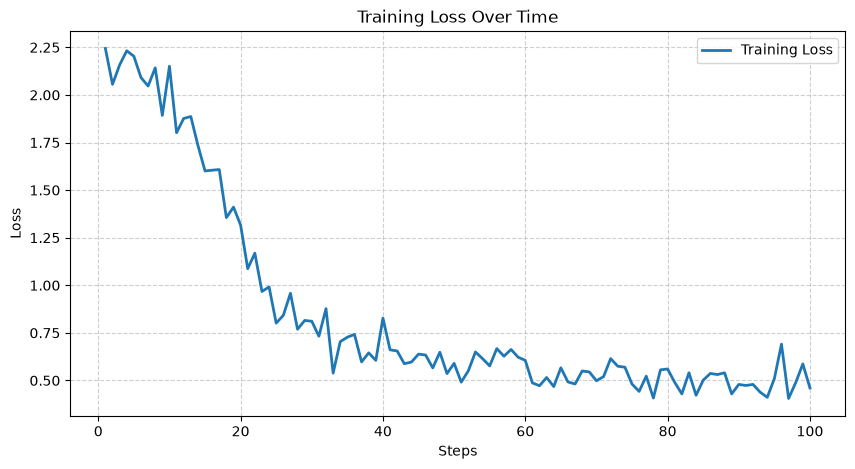

In [10]:
import matplotlib.pyplot as plt

# Extract steps and loss values from trainer log history
steps = [entry["step"] for entry in trainer.state.log_history if "loss" in entry]
losses = [entry["loss"] for entry in trainer.state.log_history if "loss" in entry]

# Create the plot
plt.figure(figsize=(10, 5))
plt.plot(steps, losses, label="Training Loss", color="#1f77b4", linewidth=2)
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training Loss Over Time")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

In [8]:
# save only the LoRA adapter
adapter_path = "./adapters/echobot_pilot"

model.save_pretrained(adapter_path)
tokenizer.save_pretrained(adapter_path)

print(f"Saved LoRA adapter to {adapter_path}")

/home/mkpuzon/code/fine-tuning/.venv/lib/python3.13/site-packages/peft/utils/save_and_load.py:438: UserWarning: Could not find a config file in Qwen/Qwen3.5-0.8B - will assume that the vocabulary was not modified.
  warnings.warn(
Unsloth: Restored added_tokens_decoder metadata in ./adapters/echobot_pilot/tokenizer_config.json.


Saved LoRA adapter to ./adapters/echobot_pilot


# Batch Size Testing


--- Starting experiment with per_device_train_batch_size = 1 ---
==((====))==  Unsloth 2026.8.12: Fast Qwen3_5 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100 80GB PCIe. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 8.0. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Unsloth: Explicit target_modules are constrained by the finetune_(vision|language|attention|mlp) filters; adapters attach only where both select.


Unsloth: Tokenizing ["text"]:   0%|          | 0/32 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 32 | Num Epochs = 13 | Total steps = 100
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 3,194,880 of 856,180,800 (0.37% trained)


...

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Unsloth: Explicit target_modules are constrained by the finetune_(vision|language|attention|mlp) filters; adapters attach only where both select.


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 32 | Num Epochs = 100 | Total steps = 100
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 4 x 1) = 32
 "-____-"     Trainable parameters = 3,194,880 of 856,180,800 (0.37% trained)


Step,Training Loss
1,2.185237
2,2.185237
3,2.184401
4,2.178688
5,2.179172
6,2.166874
7,2.146515
8,2.114251
9,2.064816
10,2.012694


/home/mkpuzon/code/fine-tuning/.venv/lib/python3.13/site-packages/peft/utils/save_and_load.py:438: UserWarning: Could not find a config file in unsloth/Qwen3.5-0.8B - will assume that the vocabulary was not modified.
  warnings.warn(
Unsloth: Restored added_tokens_decoder metadata in outputs_bs_8/checkpoint-100/tokenizer_config.json.


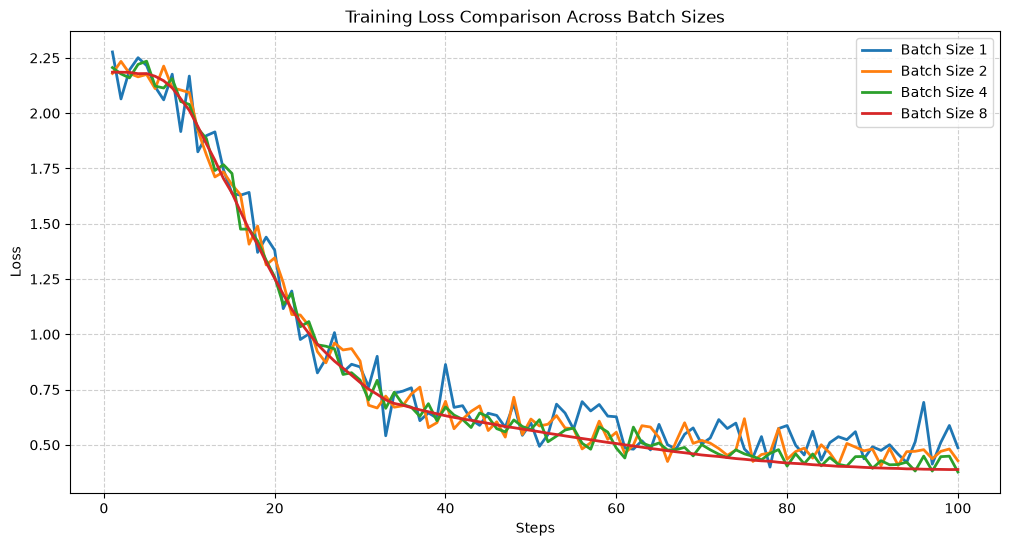

In [11]:
import gc
import torch
import matplotlib.pyplot as plt
from unsloth import FastLanguageModel

# Batch sizes you want to evaluate
batch_sizes_to_test = [1, 2, 4, 8]
results = {}

base_model_name = "unsloth/Qwen3.5-0.8B"

for bs in batch_sizes_to_test:
    print(f"\n--- Starting experiment with per_device_train_batch_size = {bs} ---")

    # 1. Load fresh base model and tokenizer
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=base_model_name,
        max_seq_length=max_seq_length,
        load_in_4bit=True,
    )

    # 2. Add LoRA adapters
    model = FastLanguageModel.get_peft_model(
        model,
        r=8,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
        lora_alpha=8,
        lora_dropout=0,
        bias="none",
        use_gradient_checkpointing="unsloth",
        random_state=8,
        max_seq_length=max_seq_length,
    )

    # 3. Configure trainer with the test batch size
    trainer = SFTTrainer(
        model=model,
        train_dataset=dataset["train"],
        tokenizer=tokenizer,
        formatting_func=formatting_func,
        args=SFTConfig(
            max_seq_length=max_seq_length,
            per_device_train_batch_size=bs,
            gradient_accumulation_steps=4,
            warmup_steps=10,
            max_steps=100,
            logging_steps=1,
            output_dir=f"outputs_bs_{bs}",
            optim="adamw_8bit",
            seed=3407,
            dataset_num_proc=1,
        ),
    )

    trainer.train()

    # 4. Save history for this run
    steps = [entry["step"] for entry in trainer.state.log_history if "loss" in entry]
    losses = [entry["loss"] for entry in trainer.state.log_history if "loss" in entry]
    results[f"Batch Size {bs}"] = (steps, losses)

    # 5. Clear GPU VRAM memory for the next iteration
    del model, trainer
    gc.collect()
    torch.cuda.empty_cache()

# 6. Plot all batch size results on one comparison chart
plt.figure(figsize=(12, 6))

for label, (steps, losses) in results.items():
    plt.plot(steps, losses, label=label, linewidth=2)

plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training Loss Comparison Across Batch Sizes")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

For serving model on vLLM
```bash
export VLLM_ALLOW_RUNTIME_LORA_UPDATING=True

vllm serve Qwen/Qwen3.5-0.8B \
    --enable-lora \
    --max-loras 4 \
    --max-lora-rank 64
```

To load an adapter inot the LoRA pool:
```bash
curl -X POST http://localhost:8000/v1/load_lora_adapter \
  -H "Content-Type: application/json" \
  -d '{
    "lora_name": "customer_support",
    "lora_path": "/absolute/path/to/lora_adapters/echobot_1"
  }'
```

To unload an adapter inot the LoRA pool:
```bash
curl -X POST http://localhost:8000/v1/unload_lora_adapter \
  -H "Content-Type: application/json" \
  -d '{
    "lora_name": "echobot_1"
  }'
```

To select model use:
```bash
from openai import OpenAI

client = OpenAI(
    base_url="http://localhost:8000/v1",
    api_key="EMPTY",
)

response = client.chat.completions.create(
    model="Qwen/Qwen3.5-0.8B",
    messages=[
        {
            "role": "user",
            "content": "Explain our refund policy."
        }
    ],
    extra_body={
        "lora_name": "customer_support"
    },
)

print(response.choices[0].message.content)
```